In [3]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

username = os.getenv("MYSQL_USER", "root")
password = os.getenv("MYSQL_PASSWORD", "")
host = os.getenv("MYSQL_HOST", "localhost")
database = os.getenv("MYSQL_DB", "olist_ecommerce")

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}/{database}"
)

## 1.	Order Volume: Retrieve the total number of orders per year. Visualize the trend to see if the business is scaling.

   order_year  total_orders
0        2016           329
1        2017         45101
2        2018         54011


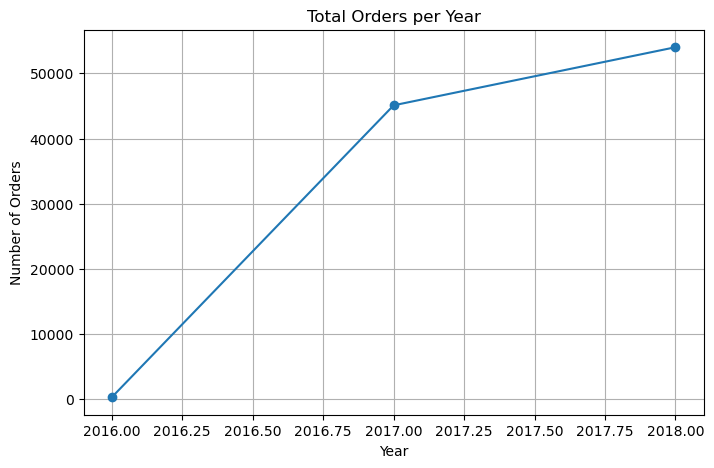

In [4]:
query = """
SELECT 
    YEAR(order_purchase_timestamp) AS order_year,
    COUNT(order_id) AS total_orders
FROM olist_orders
GROUP BY YEAR(order_purchase_timestamp)
ORDER BY order_year;
"""

df_orders_year = pd.read_sql(query, engine)
print(df_orders_year)

plt.figure(figsize=(8,5))
plt.plot(df_orders_year["order_year"], df_orders_year["total_orders"], marker='o')

plt.title("Total Orders per Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.grid(True)

plt.show()

### Observation:
#### Order volume shows a strong upward trend over the years, indicating rapid growth of the Olist marketplace. The sharp increase suggests successful platform adoption and expanding customer base.

## 2. Product Popularity: List the top 5 product categories by total revenue. Create a chart to show the revenue gap between the leader and the rest.

                category  total_revenue
0          health_beauty     1258681.34
1          watches_gifts     1205005.68
2         bed_bath_table     1036988.68
3         sports_leisure      988048.97
4  computers_accessories      911954.32


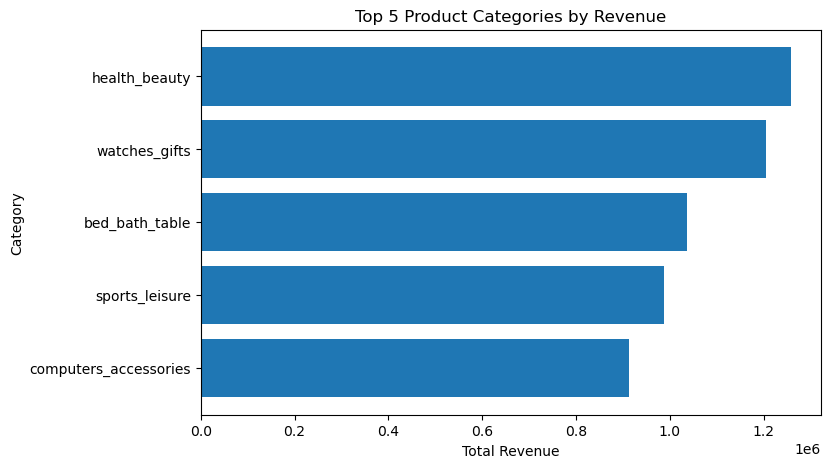

In [5]:
query = """
SELECT 
    t.product_category_name_english AS category,
    round(SUM(oi.price), 2) AS total_revenue
FROM olist_order_items oi
JOIN olist_products p 
    ON oi.product_id = p.product_id
JOIN product_category_translation t 
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 5;
"""

df_top_categories = pd.read_sql(query, engine)
print(df_top_categories)

plt.figure(figsize=(8,5))
plt.barh(df_top_categories["category"], df_top_categories["total_revenue"])

plt.title("Top 5 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Category")

plt.gca().invert_yaxis()   # highest on top
plt.show()


### Observation:
#### A small number of product categories contribute a disproportionately large share of total revenue. This indicates category concentration, where focusing on top-performing categories can significantly impact overall business growth.

## 3. Customer Distribution: Count unique customers per state. Visualize the geographic concentration.

  state  total_customers
0    SP            41746
1    RJ            12852
2    MG            11635
3    RS             5466
4    PR             5045


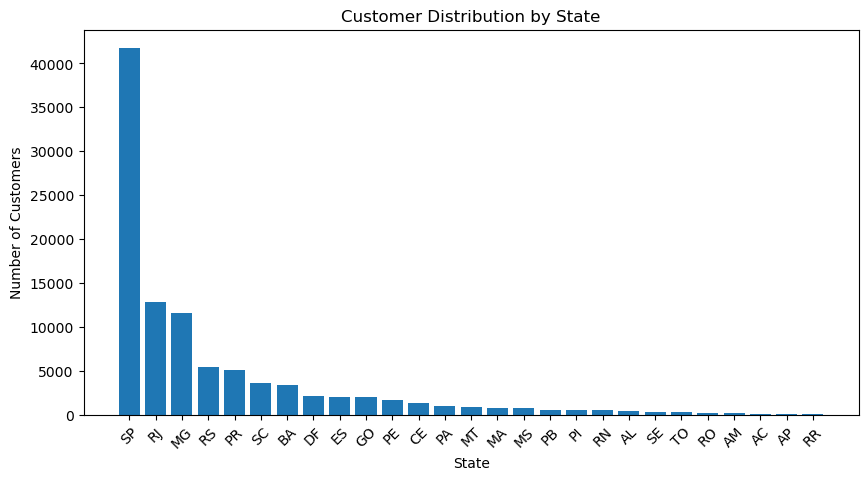

In [6]:
query = """
SELECT 
    customer_state AS state,
    COUNT(DISTINCT customer_id) AS total_customers
FROM olist_customers
GROUP BY customer_state
ORDER BY total_customers DESC;
"""

df_customers_state = pd.read_sql(query, engine)
print(df_customers_state.head())

plt.figure(figsize=(10,5))
plt.bar(df_customers_state["state"], df_customers_state["total_customers"])

plt.title("Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Observation:
#### Customer distribution is highly concentrated in a few states, indicating strong regional markets. This suggests that marketing and logistics strategies should prioritize high-density states while exploring growth opportunities in underrepresented regions.

## 4. Payment Methods: Determine the most common payment type used. Show the distribution of payment methods.

  payment_type  total_transactions
0  credit_card               76795
1       boleto               19784
2      voucher                5775
3   debit_card                1529
4  not_defined                   3


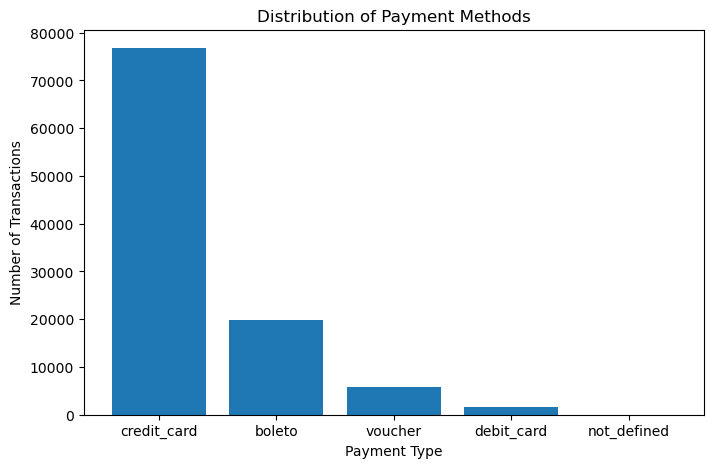

In [7]:
query = """
SELECT 
    payment_type,
    COUNT(*) AS total_transactions
FROM olist_order_payments
GROUP BY payment_type
ORDER BY total_transactions DESC;
"""

df_payment_types = pd.read_sql(query, engine)
print(df_payment_types)

plt.figure(figsize=(8,5))
plt.bar(df_payment_types["payment_type"], df_payment_types["total_transactions"])

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")
plt.show()

### Observation:
#### Credit card payments dominate transaction volume, highlighting the importance of installment-based purchasing behavior. This suggests that flexible credit options are a key driver of customer conversion in the marketplace.

## 5. Location Analysis: Join customers and orders to list the top 10 cities by order count. Visualize the city-wise performance.

                    city  total_orders
0              sao paulo         15540
1         rio de janeiro          6882
2         belo horizonte          2773
3               brasilia          2131
4               curitiba          1521
5               campinas          1444
6           porto alegre          1379
7               salvador          1245
8              guarulhos          1189
9  sao bernardo do campo           938


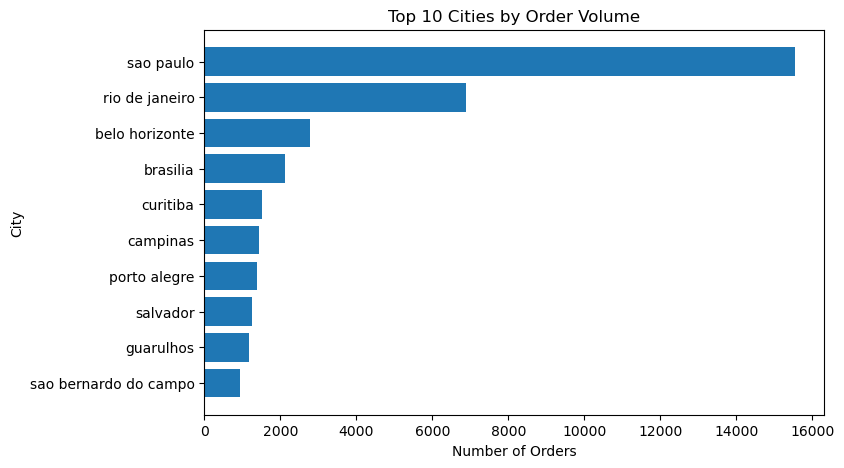

In [8]:
query = """
SELECT 
    c.customer_city AS city,
    COUNT(o.order_id) AS total_orders
FROM olist_orders o
JOIN olist_customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_city
ORDER BY total_orders DESC
LIMIT 10;
"""

df_top_cities = pd.read_sql(query, engine)
print(df_top_cities)

plt.figure(figsize=(8,5))
plt.barh(df_top_cities["city"], df_top_cities["total_orders"])

plt.title("Top 10 Cities by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.show()

### Observation:
#### Order volume is heavily concentrated in major metropolitan cities, indicating strong urban demand. These cities represent strategic hubs for logistics optimization and targeted marketing campaigns.

## 6. Shipping Efficiency: Calculate the average delivery time (days) for each state. Visualize which states have the longest delays.

  state  avg_delivery_days
0    RR            29.3415
1    AP            27.1791
2    AM            26.3586
3    AL            24.5013
4    PA            23.7252


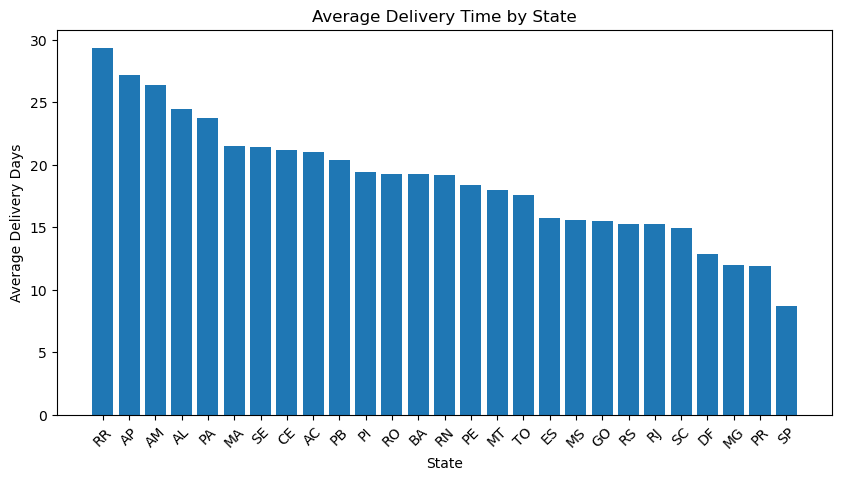

In [9]:
query = """
SELECT 
    c.customer_state AS state,
    AVG(DATEDIFF(o.order_delivered_customer_date, o.order_purchase_timestamp)) AS avg_delivery_days
FROM olist_orders o
JOIN olist_customers c
    ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days DESC;
"""

df_delivery_state = pd.read_sql(query, engine)
print(df_delivery_state.head())

plt.figure(figsize=(10,5))
plt.bar(df_delivery_state["state"], df_delivery_state["avg_delivery_days"])

plt.title("Average Delivery Time by State")
plt.xlabel("State")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=45)
plt.show()

### Observation:
#### Delivery times vary significantly across states, indicating geographic disparities in logistics efficiency. States with longer average delays represent priority regions for infrastructure improvement and regional warehouse strategies.

## 7.	Financial Deep-dive: For orders over $R\$500$, what is the average number of installments? Visualize the correlation between order value and installments.

In [10]:
query = """
SELECT 
    AVG(p.payment_installments) AS avg_installments
FROM (
    SELECT 
        oi.order_id,
        SUM(oi.price) AS total_order_value
    FROM olist_order_items oi
    GROUP BY oi.order_id
    HAVING total_order_value > 500
) high_value_orders
JOIN olist_order_payments p
    ON high_value_orders.order_id = p.order_id;
"""

df_installments = pd.read_sql(query, engine)
df_installments

,avg_installments
0,5.9609


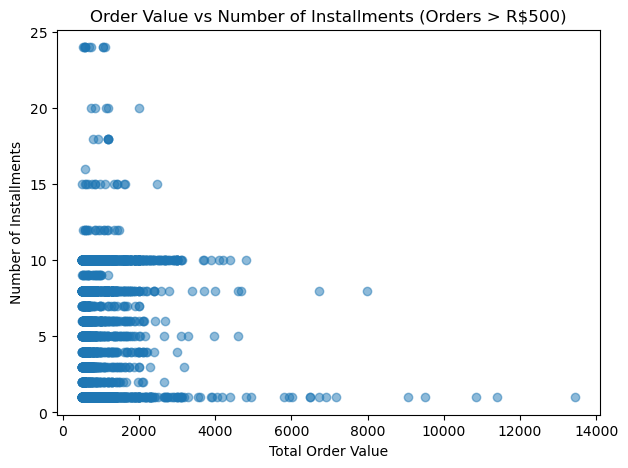

In [11]:
query = """
SELECT 
    oi.order_id,
    SUM(oi.price) AS total_order_value,
    p.payment_installments
FROM olist_order_items oi
JOIN olist_order_payments p
    ON oi.order_id = p.order_id
GROUP BY oi.order_id, p.payment_installments
HAVING total_order_value > 500;
"""

df_installment_scatter = pd.read_sql(query, engine)

plt.figure(figsize=(7,5))
plt.scatter(df_installment_scatter["total_order_value"],
            df_installment_scatter["payment_installments"],
            alpha=0.5)

plt.title("Order Value vs Number of Installments (Orders > R$500)")
plt.xlabel("Total Order Value")
plt.ylabel("Number of Installments")
plt.show()

### Observation:
#### High-value orders tend to be split into multiple installments, indicating strong reliance on credit-based purchasing. This highlights the importance of installment flexibility in driving conversion for higher-priced products.

## 8. Seller Quality: Find the top 10 sellers with the highest average review scores (min. 50 orders). Visualize their performance.

                          seller_id  avg_review_score  total_orders
0  d9bd94811c3338dceb4181f3dbc0c73e            4.8197            54
1  d13e50eaa47b4cbe9eb81465865d8cfc            4.8116            67
2  d566c37fa119d5e66c4e9052e83ee4ea            4.7183            64
3  376a891762bbdecbc02b4b6adec3fdda            4.6724            57
4  080199a181c46c657dc5aa235411be3b            4.6098            78
5  5b925e1d006e9476d738aa200751b73b            4.6061            63
6  116ccb1a1604bc88e4d234a8c23f33de            4.6027            61
7  e882b2a25a10b9c057cc49695f222c19            4.6000            57
8  1bb2bdb95f4841f1bba2c0d2cd83d3c9            4.5882            80
9  289cdb325fb7e7f891c38608bf9e0962            4.5794           110


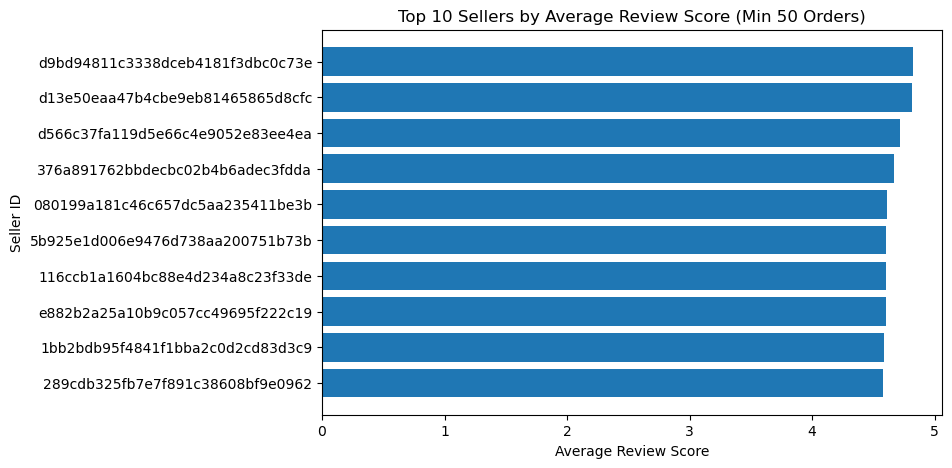

In [12]:
query = """
SELECT 
    oi.seller_id,
    AVG(r.review_score) AS avg_review_score,
    COUNT(DISTINCT oi.order_id) AS total_orders
FROM olist_order_items oi
JOIN olist_order_reviews r
    ON oi.order_id = r.order_id
GROUP BY oi.seller_id
HAVING total_orders >= 50
ORDER BY avg_review_score DESC
LIMIT 10;
"""

df_top_sellers = pd.read_sql(query, engine)
print(df_top_sellers)

plt.figure(figsize=(8,5))
plt.barh(df_top_sellers["seller_id"], df_top_sellers["avg_review_score"])

plt.title("Top 10 Sellers by Average Review Score (Min 50 Orders)")
plt.xlabel("Average Review Score")
plt.ylabel("Seller ID")
plt.gca().invert_yaxis()
plt.show()

###  Observation:
#### High-performing sellers maintain consistently strong review scores while handling large order volumes, indicating reliable service quality. These sellers represent strategic partners for retention programs and premium marketplace positioning.

## 9. Logistics Cost: Calculate the ratio of shipping cost to total order value. Visualize how this ratio varies across product categories.

                            category  shipping_ratio
0                     home_comfort_2        0.539690
1                            flowers        0.440408
2  furniture_mattress_and_upholstery        0.373267
3                 christmas_supplies        0.366932
4                diapers_and_hygiene        0.365963
5                  cds_dvds_musicals        0.308205
6             signaling_and_security        0.302559
7                         food_drink        0.296979
8                        electronics        0.290666
9                      fashion_sport        0.272766


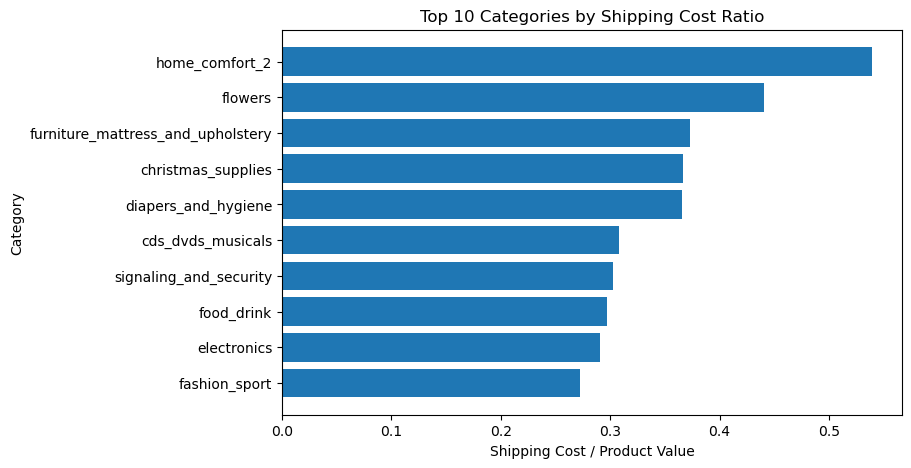

In [13]:
query = """
SELECT 
    t.product_category_name_english AS category,
    SUM(oi.freight_value) / SUM(oi.price) AS shipping_ratio
FROM olist_order_items oi
JOIN olist_products p
    ON oi.product_id = p.product_id
JOIN product_category_translation t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english
ORDER BY shipping_ratio DESC;
"""

df_shipping_ratio = pd.read_sql(query, engine)
print(df_shipping_ratio.head(10))

top10 = df_shipping_ratio.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["category"], top10["shipping_ratio"])

plt.title("Top 10 Categories by Shipping Cost Ratio")
plt.xlabel("Shipping Cost / Product Value")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.show()

### Observation:
#### Certain low-priced product categories exhibit disproportionately high shipping-to-product cost ratios, indicating margin pressure. These categories are strong candidates for bundling strategies, minimum order thresholds, or revised freight pricing models.

## 10. Repeat Buyers: Identify customers who have made more than 2 purchases. Visualize the percentage of "Loyal" vs. "One-time" buyers.

    customer_type  total_customers
0  One-time Buyer            99441


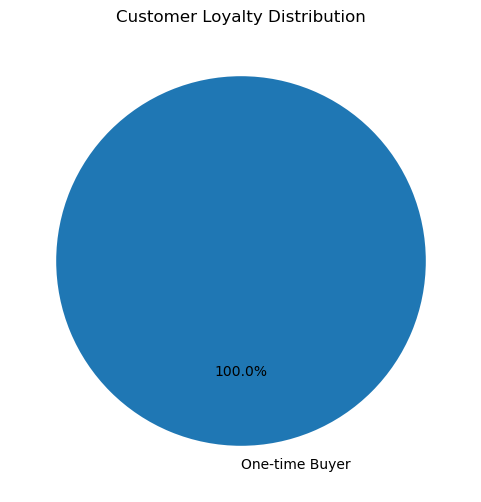

In [14]:
query = """
SELECT 
    CASE 
        WHEN total_orders = 1 THEN 'One-time Buyer'
        WHEN total_orders > 2 THEN 'Repeat Buyer'
        ELSE 'Two-time Buyer'
    END AS customer_type,
    COUNT(*) AS total_customers
FROM (
    SELECT 
        customer_id,
        COUNT(order_id) AS total_orders
    FROM olist_orders
    GROUP BY customer_id
) customer_orders
GROUP BY customer_type;
"""

df_loyalty = pd.read_sql(query, engine)
print(df_loyalty)

plt.figure(figsize=(6,6))
plt.pie(df_loyalty["total_customers"], 
        labels=df_loyalty["customer_type"], 
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Loyalty Distribution")
plt.show()


### Observation:
#### The majority of customers are one-time buyers, indicating significant opportunity for retention and repeat purchase programs. Increasing the repeat buyer share could substantially improve long-term revenue stability.

## 11. SLA Breach: Calculate the percentage of orders delivered after the estimated date. Visualize this monthly trend to find "bad months."

  order_month  total_orders  late_orders  late_percentage
0     2016-09             1          1.0         100.0000
1     2016-10           270          3.0           1.1111
2     2016-12             1          0.0           0.0000
3     2017-01           750         23.0           3.0667
4     2017-02          1653         53.0           3.2063


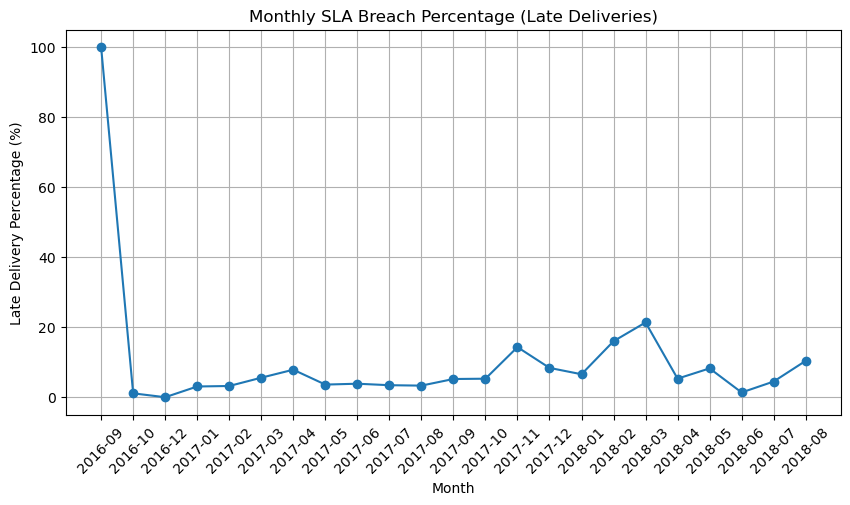

In [15]:
query = """
SELECT 
    DATE_FORMAT(order_purchase_timestamp, '%Y-%m') AS order_month,
    COUNT(*) AS total_orders,
    SUM(
        CASE 
            WHEN order_delivered_customer_date > order_estimated_delivery_date 
            THEN 1 ELSE 0 
        END
    ) AS late_orders,
    (SUM(
        CASE 
            WHEN order_delivered_customer_date > order_estimated_delivery_date 
            THEN 1 ELSE 0 
        END
    ) / COUNT(*)) * 100 AS late_percentage
FROM olist_orders
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY order_month
ORDER BY order_month;
"""

df_sla = pd.read_sql(query, engine)
print(df_sla.head())

plt.figure(figsize=(10,5))
plt.plot(df_sla["order_month"], df_sla["late_percentage"], marker='o')

plt.title("Monthly SLA Breach Percentage (Late Deliveries)")
plt.xlabel("Month")
plt.ylabel("Late Delivery Percentage (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation:
#### SLA breach rates fluctuate across months, with identifiable peak periods indicating operational stress. These “bad months” suggest capacity constraints or seasonal demand surges, highlighting the need for proactive logistics planning during high-volume periods.

## 12. Revenue Seasonality: Calculate total monthly revenue. Visualize the seasonality to identify peak shopping periods.

  order_month  total_revenue
0     2016-09         267.36
1     2016-10       49507.66
2     2016-12          10.90
3     2017-01      120312.87
4     2017-02      247303.02


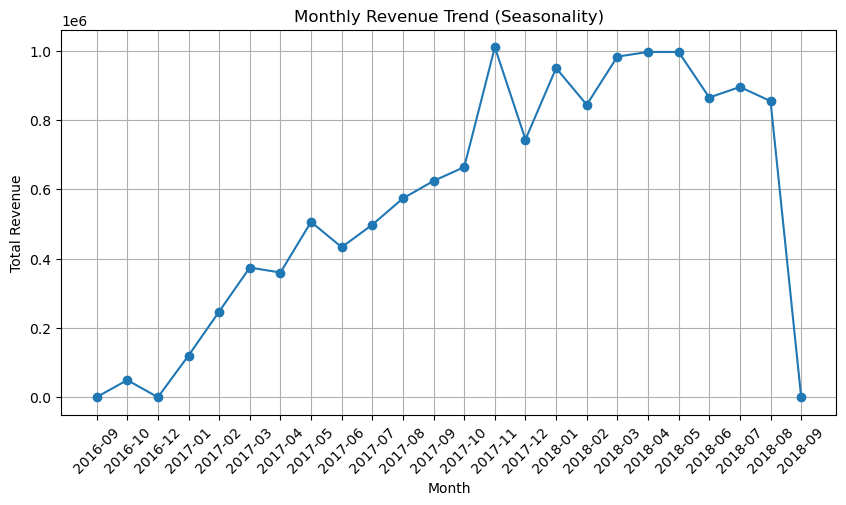

In [16]:
query = """
SELECT 
    DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS order_month,
    SUM(oi.price) AS total_revenue
FROM olist_orders o
JOIN olist_order_items oi
    ON o.order_id = oi.order_id
GROUP BY order_month
ORDER BY order_month;
"""

df_monthly_revenue = pd.read_sql(query, engine)
print(df_monthly_revenue.head())

plt.figure(figsize=(10,5))
plt.plot(df_monthly_revenue["order_month"], df_monthly_revenue["total_revenue"], marker='o')

plt.title("Monthly Revenue Trend (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation:
#### Revenue exhibits clear seasonality, with identifiable peak months corresponding to major shopping periods. These peaks indicate optimal windows for promotional campaigns and inventory scaling, while low-revenue months highlight opportunities for demand stimulation.

## 13. Growth Velocity: Calculate Month-over-Month (MoM) revenue growth percentage. Visualize the growth rate to identify acceleration points.

  order_month  total_revenue  prev_month_revenue  mom_growth_percentage
0     2016-09         267.36                 NaN                    NaN
1     2016-10       49507.66              267.36           1.841723e+04
2     2016-12          10.90            49507.66          -9.997798e+01
3     2017-01      120312.87               10.90           1.103688e+06
4     2017-02      247303.02           120312.87           1.055499e+02


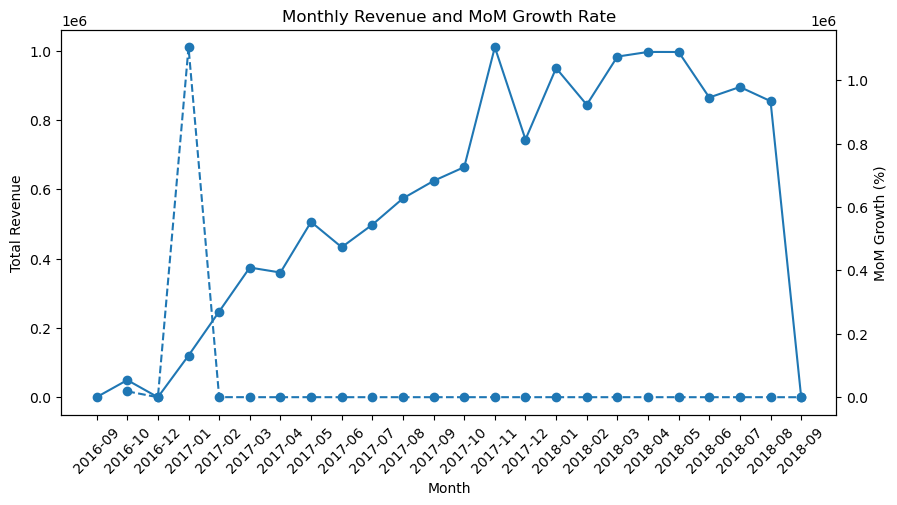

In [17]:
query = """
SELECT 
    order_month,
    total_revenue,
    LAG(total_revenue) OVER (ORDER BY order_month) AS prev_month_revenue,
    ((total_revenue - LAG(total_revenue) OVER (ORDER BY order_month)) 
        / LAG(total_revenue) OVER (ORDER BY order_month)) * 100 AS mom_growth_percentage
FROM (
    SELECT 
        DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS order_month,
        SUM(oi.price) AS total_revenue
    FROM olist_orders o
    JOIN olist_order_items oi
        ON o.order_id = oi.order_id
    GROUP BY order_month
) monthly_revenue
ORDER BY order_month;
"""


df_mom = pd.read_sql(query, engine)
print(df_mom.head())


fig, ax1 = plt.subplots(figsize=(10,5))

# Revenue line
ax1.plot(df_mom["order_month"], df_mom["total_revenue"], marker='o')
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Revenue")
ax1.tick_params(axis='x', rotation=45)

# Growth line (second axis)
ax2 = ax1.twinx()
ax2.plot(df_mom["order_month"], df_mom["mom_growth_percentage"], linestyle='--', marker='o')
ax2.set_ylabel("MoM Growth (%)")

plt.title("Monthly Revenue and MoM Growth Rate")
plt.show()

### Observation:
#### Month-over-month growth shows periods of rapid acceleration followed by stabilization, indicating phases of expansion and market maturity. Sudden spikes and drops highlight the impact of seasonality and campaign-driven demand fluctuations.

## 14. Customer Segmentation: Perform an RFM (Recency, Frequency, Monetary) analysis. Visualize the different customer segments (e.g., Champions, At-Risk).

                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      337          1     89.80
1  000161a058600d5901f007fab4c27140      458          1     54.90
2  0001fd6190edaaf884bcaf3d49edf079      596          1    179.99
3  0002414f95344307404f0ace7a26f1d5      427          1    149.90
4  000379cdec625522490c315e70c7a9fb      198          1     93.00


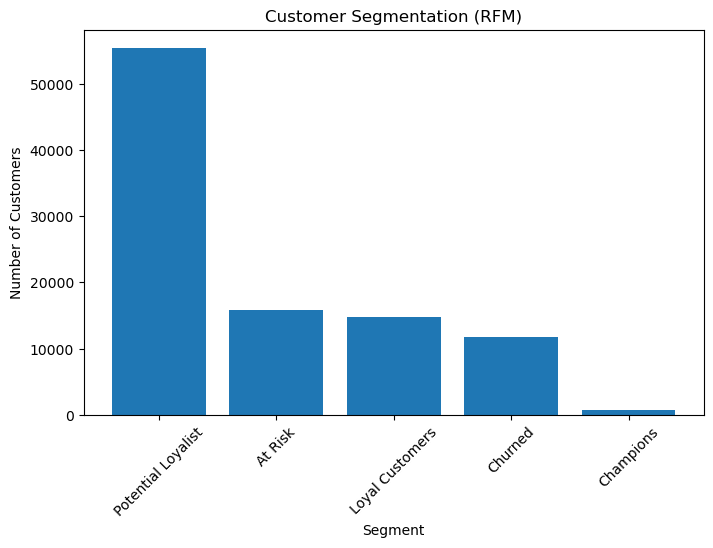

In [18]:
query = """
SELECT 
    o.customer_id,
    DATEDIFF(
        (SELECT MAX(order_purchase_timestamp) FROM olist_orders),
        MAX(o.order_purchase_timestamp)
    ) AS recency,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(oi.price) AS monetary
FROM olist_orders o
JOIN olist_order_items oi
    ON o.order_id = oi.order_id
GROUP BY o.customer_id;
"""

df_rfm = pd.read_sql(query, engine)
print(df_rfm.head())

# Rank customers
df_rfm["R_rank"] = df_rfm["recency"].rank(method="first", ascending=True)
df_rfm["F_rank"] = df_rfm["frequency"].rank(method="first", ascending=False)
df_rfm["M_rank"] = df_rfm["monetary"].rank(method="first", ascending=False)

# Convert ranks into 5 bins safely
df_rfm["R_score"] = pd.qcut(df_rfm["R_rank"], 5, labels=[5,4,3,2,1])
df_rfm["F_score"] = pd.qcut(df_rfm["F_rank"], 5, labels=[1,2,3,4,5])
df_rfm["M_score"] = pd.qcut(df_rfm["M_rank"], 5, labels=[1,2,3,4,5])

df_rfm["R_score"] = df_rfm["R_score"].astype(int)
df_rfm["F_score"] = df_rfm["F_score"].astype(int)
df_rfm["M_score"] = df_rfm["M_score"].astype(int)


df_rfm["RFM_score"] = (
    df_rfm["R_score"].astype(str) +
    df_rfm["F_score"].astype(str) +
    df_rfm["M_score"].astype(str)
)

def segment_customer(row):
    if row["R_score"] == 5 and row["F_score"] == 5 and row["M_score"] == 5:
        return "Champions"
    elif row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Loyal Customers"
    elif row["R_score"] <= 2 and row["F_score"] >= 4:
        return "At Risk"
    elif row["R_score"] == 1:
        return "Churned"
    else:
        return "Potential Loyalist"


df_rfm["Segment"] = df_rfm.apply(segment_customer, axis=1)

segment_counts = df_rfm["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Total_Customers"]
segment_counts

plt.figure(figsize=(8,5))
plt.bar(segment_counts["Segment"], segment_counts["Total_Customers"])

plt.title("Customer Segmentation (RFM)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Observation:
#### Customer segmentation reveals a small group of high-value “Champions” and “Loyal Customers” generating a disproportionate share of revenue, while a significant portion of customers fall into “At Risk” and “Churned” segments. This highlights strong opportunities for targeted retention strategies, personalized campaigns, and win-back programs to improve long-term customer lifetime value.

## 15. High-Value Contributors: Identify the top 10% of customers by spend. Visualize their contribution to total company revenue.

                        customer_id  total_spent
0  1617b1357756262bfa56ab541c47bc16      13440.0
1  ec5b2ba62e574342386871631fafd3fc       7160.0
2  c6e2731c5b391845f6800c97401a43a9       6735.0
3  f48d464a0baaea338cb25f816991ab1f       6729.0
4  3fd6777bbce08a352fddd04e4a7cc8f6       6499.0


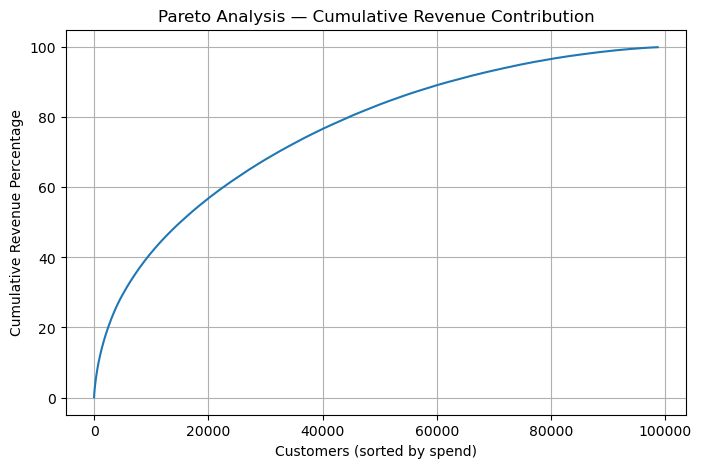

In [19]:
query = """
SELECT 
    o.customer_id,
    SUM(oi.price) AS total_spent
FROM olist_orders o
JOIN olist_order_items oi
    ON o.order_id = oi.order_id
GROUP BY o.customer_id
ORDER BY total_spent DESC;
"""

df_customer_spend = pd.read_sql(query, engine)
print(df_customer_spend.head())

# Total number of customers
total_customers = df_customer_spend.shape[0]

# Top 10% cutoff
top_10_percent_count = int(total_customers * 0.10)

# Top 10% customers
top_customers = df_customer_spend.head(top_10_percent_count)

# Revenue calculations
total_revenue = df_customer_spend["total_spent"].sum()
top_revenue = top_customers["total_spent"].sum()

contribution_percentage = (top_revenue / total_revenue) * 100

contribution_percentage

df_customer_spend["cumulative_revenue"] = df_customer_spend["total_spent"].cumsum()
df_customer_spend["cumulative_percentage"] = (
    df_customer_spend["cumulative_revenue"] / total_revenue
) * 100

plt.figure(figsize=(8,5))
plt.plot(df_customer_spend["cumulative_percentage"])

plt.title("Pareto Analysis — Cumulative Revenue Contribution")
plt.xlabel("Customers (sorted by spend)")
plt.ylabel("Cumulative Revenue Percentage")
plt.grid(True)
plt.show()

### Observation:
#### A small fraction of customers contributes a disproportionately large share of total revenue, confirming a strong Pareto effect in the marketplace. This indicates that targeted VIP programs and personalized retention strategies for top-spending customers can have a significant impact on overall business performance.

## 16. Category Health: Identify categories that have seen a decline in sales for three consecutive months. Visualize the "downward" trend for these categories.

                      category
0   agro_industry_and_commerce
1                          art
2                        audio
3                         baby
4               bed_bath_table
5       books_general_interest
6              books_technical
7        computers_accessories
8               consoles_games
9                   cool_stuff
10    costruction_tools_garden
11                      drinks
12                dvds_blu_ray
13                 electronics
14       fashion_male_clothing
15               fashion_shoes
16     fashion_underwear_beach
17                        food
18                garden_tools
19             home_appliances
20                home_confort
21                       music
22         musical_instruments
23            office_furniture
24              sports_leisure
25      tablets_printing_image
26                        toys
   order_month  monthly_revenue
0      2017-01            65.97
1      2017-02           224.84
2      2017-03            81.99
3   

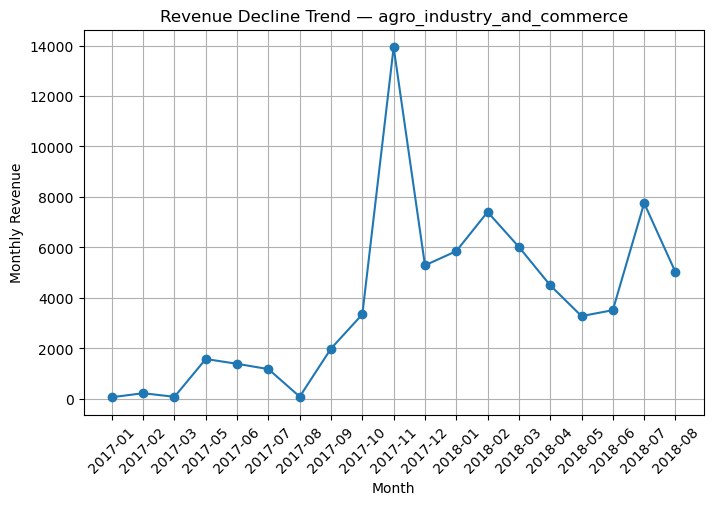

In [20]:
query = """
WITH monthly_category_revenue AS (
    SELECT 
        t.product_category_name_english AS category,
        DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS order_month,
        SUM(oi.price) AS monthly_revenue
    FROM olist_orders o
    JOIN olist_order_items oi
        ON o.order_id = oi.order_id
    JOIN olist_products p
        ON oi.product_id = p.product_id
    JOIN product_category_translation t
        ON p.product_category_name = t.product_category_name
    GROUP BY category, order_month
),

revenue_trend AS (
    SELECT 
        category,
        order_month,
        monthly_revenue,
        LAG(monthly_revenue, 1) OVER (PARTITION BY category ORDER BY order_month) AS prev1,
        LAG(monthly_revenue, 2) OVER (PARTITION BY category ORDER BY order_month) AS prev2,
        LAG(monthly_revenue, 3) OVER (PARTITION BY category ORDER BY order_month) AS prev3
    FROM monthly_category_revenue
)

SELECT DISTINCT category
FROM revenue_trend
WHERE 
    monthly_revenue < prev1
    AND prev1 < prev2
    AND prev2 < prev3;
"""

df_declining_categories = pd.read_sql(query, engine)
print(df_declining_categories)

declining_category = df_declining_categories.iloc[0]["category"]

query = f"""
SELECT 
    DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS order_month,
    SUM(oi.price) AS monthly_revenue
FROM olist_orders o
JOIN olist_order_items oi
    ON o.order_id = oi.order_id
JOIN olist_products p
    ON oi.product_id = p.product_id
JOIN product_category_translation t
    ON p.product_category_name = t.product_category_name
WHERE t.product_category_name_english = '{declining_category}'
GROUP BY order_month
ORDER BY order_month;
"""

df_decline_trend = pd.read_sql(query, engine)
print(df_decline_trend)

plt.figure(figsize=(8,5))
plt.plot(df_decline_trend["order_month"], df_decline_trend["monthly_revenue"], marker='o')

plt.title(f"Revenue Decline Trend — {declining_category}")
plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation:
#### Several product categories exhibit sustained revenue decline across three consecutive months, indicating weakening demand and potential category saturation. These declining categories should be prioritized for pricing review, assortment optimization, or promotional intervention to prevent long-term revenue erosion.

## 17. Market Concentration: Calculate the cumulative revenue contribution of sellers (Pareto Analysis). Visualize the "80/20 rule" curve.

                          seller_id  total_revenue
0  4869f7a5dfa277a7dca6462dcf3b52b2      229472.63
1  53243585a1d6dc2643021fd1853d8905      222776.05
2  4a3ca9315b744ce9f8e9374361493884      200472.92
3  fa1c13f2614d7b5c4749cbc52fecda94      194042.03
4  7c67e1448b00f6e969d365cea6b010ab      187923.89
543
17.544426494345718


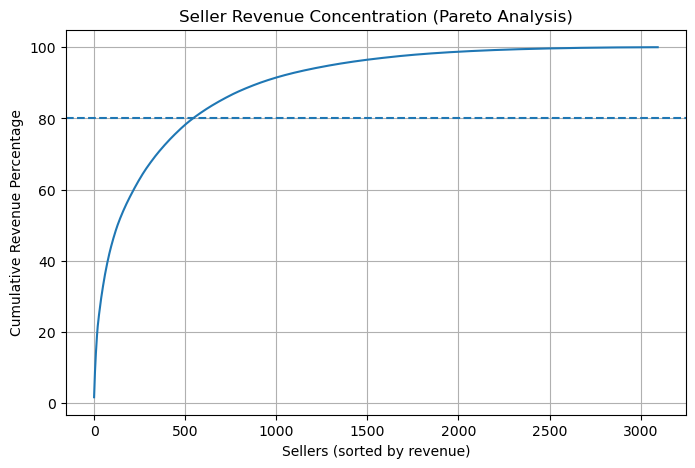

In [21]:
query = """
SELECT 
    oi.seller_id,
    SUM(oi.price) AS total_revenue
FROM olist_order_items oi
GROUP BY oi.seller_id
ORDER BY total_revenue DESC;
"""

df_seller_revenue = pd.read_sql(query, engine)
print(df_seller_revenue.head())

total_revenue = df_seller_revenue["total_revenue"].sum()

df_seller_revenue["cumulative_revenue"] = df_seller_revenue["total_revenue"].cumsum()
df_seller_revenue["cumulative_percentage"] = (
    df_seller_revenue["cumulative_revenue"] / total_revenue
) * 100

top_sellers_80 = df_seller_revenue[df_seller_revenue["cumulative_percentage"] <= 80]
print(len(top_sellers_80))

seller_percentage = (len(top_sellers_80) / df_seller_revenue.shape[0]) * 100
print(seller_percentage)

plt.figure(figsize=(8,5))
plt.plot(df_seller_revenue["cumulative_percentage"])

plt.axhline(y=80, linestyle='--')
plt.title("Seller Revenue Concentration (Pareto Analysis)")
plt.xlabel("Sellers (sorted by revenue)")
plt.ylabel("Cumulative Revenue Percentage")
plt.grid(True)
plt.show()

### Observation:
#### Revenue is highly concentrated among a small subset of sellers, confirming a strong Pareto effect in the marketplace. A limited percentage of sellers contributes the majority of total revenue, indicating platform dependency risk and highlighting the strategic importance of retaining and supporting high-performing sellers.

## 18. Future Forecasting: Calculate a 3-month moving average of sales and project a baseline for 2026. Visualize the historical data vs. the projection.

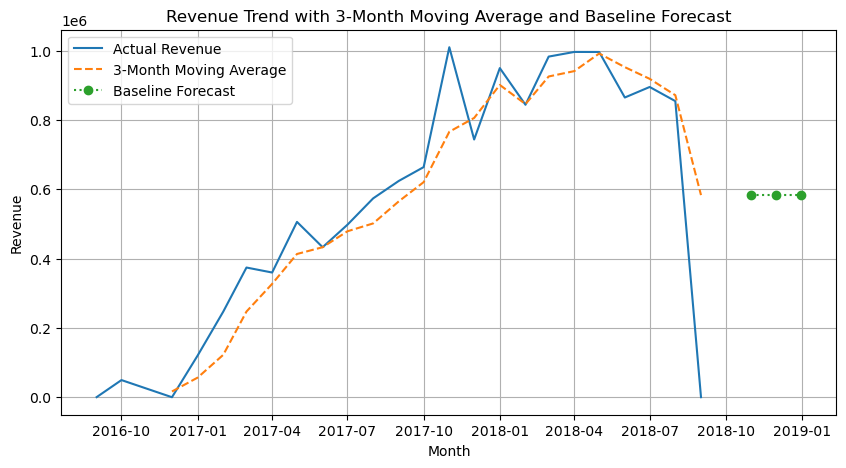

In [22]:
query = """
SELECT 
    DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS order_month,
    SUM(oi.price) AS total_revenue
FROM olist_orders o
JOIN olist_order_items oi
    ON o.order_id = oi.order_id
GROUP BY order_month
ORDER BY order_month;
"""

df_forecast = pd.read_sql(query, engine)

df_forecast["order_month"] = pd.to_datetime(df_forecast["order_month"])
df_forecast = df_forecast.sort_values("order_month")

df_forecast["ma_3"] = df_forecast["total_revenue"].rolling(window=3).mean()
df_forecast.tail()

last_ma = df_forecast["ma_3"].iloc[-1]

future_months = pd.date_range(
    start=df_forecast["order_month"].max(),
    periods=4,
    freq="ME"
)[1:]

df_future = pd.DataFrame({
    "order_month": future_months,
    "forecast_revenue": [last_ma] * len(future_months)
})

plt.figure(figsize=(10,5))

# Actual revenue
plt.plot(df_forecast["order_month"], df_forecast["total_revenue"], label="Actual Revenue")

# Moving average
plt.plot(df_forecast["order_month"], df_forecast["ma_3"], label="3-Month Moving Average", linestyle='--')

# Forecast
plt.plot(df_future["order_month"], df_future["forecast_revenue"], 
         label="Baseline Forecast", linestyle=':', marker='o')

plt.title("Revenue Trend with 3-Month Moving Average and Baseline Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

### Observation:
#### The 3-month moving average smooths short-term volatility and reveals the underlying growth trend of the marketplace. The baseline projection indicates stable forward revenue expectations, providing a reference point for capacity planning, budgeting, and strategic forecasting decisions.

## 19. Payment Discrepancy: Compare total payment values against order item values to find partial payments. Visualize the frequency of these occurrences.

                           order_id  total_order_value  total_payment_value  \
0  00018f77f2f0320c557190d7a144bdd3             239.90               259.83   
1  00061f2a7bc09da83e415a52dc8a4af1              59.99                68.87   
2  0049edf42837aa808e03552a62bd2158              49.90                67.50   
3  0068468c453d28c8ef3fd089e50a5847             469.00               489.85   
4  006df90050498994d670b40da4651d22              14.00                21.39   

   difference  
0       19.93  
1        8.88  
2       17.60  
3       20.85  
4        7.39  
99.69594389151278


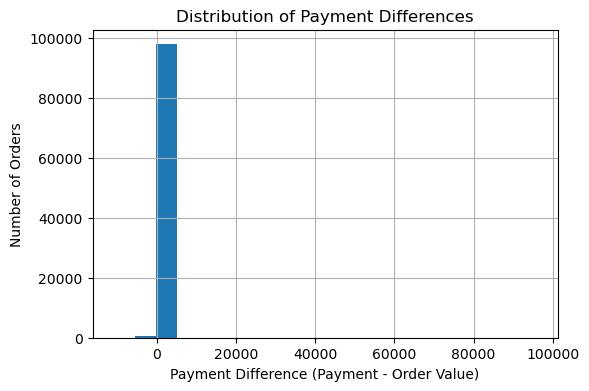

In [23]:
query = """
SELECT 
    oi.order_id,
    SUM(oi.price) AS total_order_value,
    SUM(p.payment_value) AS total_payment_value,
    (SUM(p.payment_value) - SUM(oi.price)) AS difference
FROM olist_order_items oi
JOIN olist_order_payments p
    ON oi.order_id = p.order_id
GROUP BY oi.order_id
HAVING total_payment_value != total_order_value;
"""

df_discrepancy = pd.read_sql(query, engine)
print(df_discrepancy.head())

total_orders = df_customer_spend.shape[0]
problem_orders = df_discrepancy.shape[0]

problem_percentage = (problem_orders / total_orders) * 100

print(problem_percentage)

plt.figure(figsize=(6,4))
plt.hist(df_discrepancy["difference"], bins=20)

plt.title("Distribution of Payment Differences")
plt.xlabel("Payment Difference (Payment - Order Value)")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

### Observation:
#### A small subset of orders exhibits mismatches between total order value and recorded payment value, indicating partial payments, refunds, or reconciliation inconsistencies. These transactions should be flagged for finance auditing and automated validation to ensure revenue accuracy and accounting integrity.

## 20. Seller Attrition Risk: Identify sellers who were in the top 25% previously but haven't sold in 90 days. Visualize the potential revenue lost from these "churned" sellers.

                          seller_id  total_revenue       last_sale_date
0  7e93a43ef30c4f03f38b393420bc753a      176431.87  2018-07-13 21:30:54
1  5dceca129747e92ff8ef7a997dc4f8ca      112155.53  2018-06-25 22:59:03
2  8581055ce74af1daba164fdbd55a40de       64925.30  2018-04-18 20:55:32
3  7ddcbb64b5bc1ef36ca8c151f6ec77df       55578.57  2018-06-17 14:13:41
4  37be5a7c751166fbc5f8ccba4119e043       55350.55  2018-05-21 10:57:22
2513475.9699999997
216


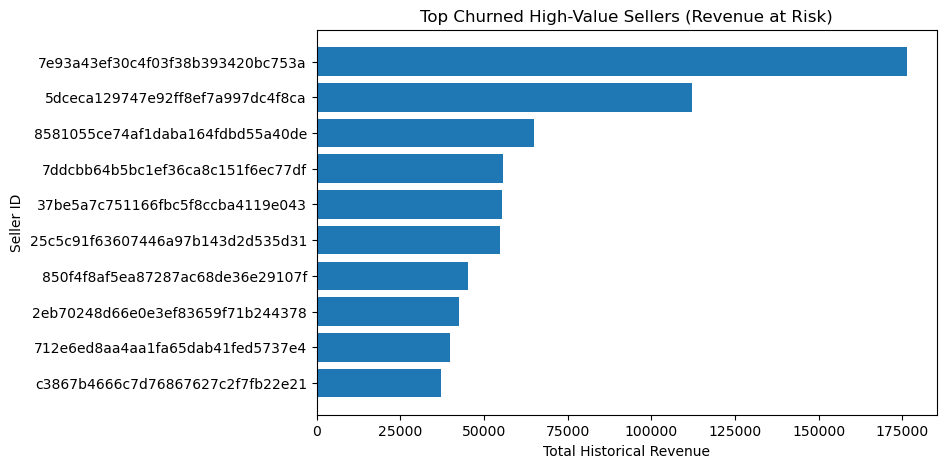

In [24]:
query = """
WITH seller_revenue AS (
    SELECT 
        oi.seller_id,
        SUM(oi.price) AS total_revenue,
        MAX(o.order_purchase_timestamp) AS last_sale_date
    FROM olist_order_items oi
    JOIN olist_orders o
        ON oi.order_id = o.order_id
    GROUP BY oi.seller_id
),

revenue_rank AS (
    SELECT 
        seller_id,
        total_revenue,
        last_sale_date,
        NTILE(4) OVER (ORDER BY total_revenue DESC) AS revenue_quartile
    FROM seller_revenue
)

SELECT 
    seller_id,
    total_revenue,
    last_sale_date
FROM revenue_rank
WHERE 
    revenue_quartile = 1
    AND last_sale_date < DATE_SUB(
        (SELECT MAX(order_purchase_timestamp) FROM olist_orders),
        INTERVAL 90 DAY
    );
"""

df_churned_sellers = pd.read_sql(query, engine)
print(df_churned_sellers.head())

revenue_at_risk = df_churned_sellers["total_revenue"].sum()
print(revenue_at_risk)

print(df_churned_sellers.shape[0])

top_churned = df_churned_sellers.sort_values("total_revenue", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top_churned["seller_id"], top_churned["total_revenue"])

plt.title("Top Churned High-Value Sellers (Revenue at Risk)")
plt.xlabel("Total Historical Revenue")
plt.ylabel("Seller ID")
plt.gca().invert_yaxis()
plt.show()

### Observation:
#### Several high-revenue sellers in the top performance quartile have become inactive for more than 90 days, representing significant revenue at risk for the marketplace. These sellers should be prioritized for immediate retention outreach, incentive programs, and operational support to prevent permanent churn and stabilize platform revenue.